# DBSCAN — Density-Based Clustering of Personality Profiles

## What is DBSCAN?

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** finds clusters as **dense regions** separated by sparse regions — without requiring you to specify K in advance.

It classifies each point as:
- **Core point:** has at least `min_samples` neighbors within radius `eps`
- **Border point:** within `eps` of a core point but not itself a core point
- **Noise point (outlier):** not within `eps` of any core point → labeled **-1**

### Why DBSCAN on personality data?
- Finds personality clusters **without assuming how many there are**
- Explicitly identifies **personality outliers** — people who don't fit any profile
- Handles **non-spherical cluster shapes** (unlike K-Means)
- Useful for detecting unusual Big Five + OCB/CWB combinations

### Key parameters
| Parameter | What it controls |
|---|---|
| `eps` | Neighborhood radius — how close two points must be to be neighbors |
| `min_samples` | Minimum neighbors to be a core point — higher = stricter clusters |

### Pipeline
```
Big Five traits + OCB + CWB
        ↓
StandardScaler
        ↓
K-distance plot → choose eps
        ↓
DBSCAN fit
        ↓
Profile clusters + inspect outliers
```

## 1. Preprocessing data, import require packages, prepare features for DBSCAN

In [26]:
import json
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

print("✓ Imports complete")


repo_root = Path.cwd().resolve()
while not (repo_root / "BFI_2_life_narative_metadata.json").exists():
    if repo_root == repo_root.parent:
        raise FileNotFoundError("Could not find BFI_2_life_narative_metadata.json")
    repo_root = repo_root.parent

# Load data
with open(repo_root / "BFI_2_life_narative_metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

with open(repo_root / "BFI_2_life_narrative.json", "r", encoding="utf-8") as f:
    responses = json.load(f)

df = pd.DataFrame(responses)

# Reverse-code BFI items
reverse_items = metadata["reverse_code_items"]

for item in reverse_items:
    if item in df.columns:
        df[item] = 6 - df[item]

# Big Five trait means
traits = {
    key: value
    for key, value in metadata.items()
    if (
        isinstance(value, list)
        and value
        and isinstance(value[0], str)
        and value[0].startswith("Item")
        and not key.startswith(("Item", "Q", "CWB", "OCB"))
        and key != "reverse_code_items"
    )
}

for trait, items in traits.items():
    available_items = [item for item in items if item in df.columns]
    df[trait] = df[available_items].mean(axis=1)

# CWB and OCB means
cwb_cols = [f"CWB{i}" for i in range(1, 11) if f"CWB{i}" in df.columns]
ocb_cols = [f"OCB{i}" for i in range(1, 11) if f"OCB{i}" in df.columns]

df["CWB"] = df[cwb_cols].mean(axis=1)
df["OCB"] = df[ocb_cols].mean(axis=1)

features = ["Extraversion", "Agreeableness", "Conscientiousness",
            "Neuroticism", "Openness", "OCB", "CWB"]

X_raw    = df[features].dropna().reset_index(drop=True)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA for 2D visualization
pca2   = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

print(f"Samples : {X_scaled.shape[0]}")
print(f"Features: {features}")

✓ Imports complete
Samples : 500
Features: ['Extraversion', 'Agreeableness', 'Conscientiousness', 'Neuroticism', 'Openness', 'OCB', 'CWB']


## 2. Choose eps — K-Distance plot

The **k-distance plot** is the standard method for choosing `eps`:
1. For each point, compute the distance to its K-th nearest neighbor
2. Sort these distances and plot them
3. The **elbow** of this curve is a good choice for `eps`

We use K = `min_samples - 1` (typically set to `2 × n_features - 1`).

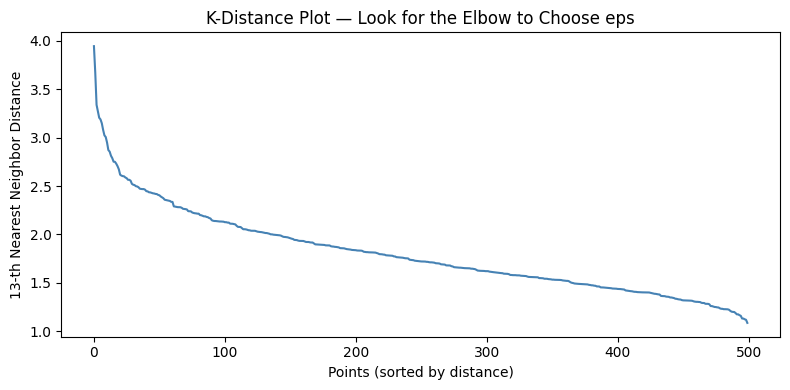

Suggested min_samples: 13
Set eps at the elbow of the curve above.


In [ ]:
min_samples = 2 * len(features) - 1  # rule of thumb
k_dist      = min_samples

nbrs = NearestNeighbors(n_neighbors=k_dist).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances  = np.sort(distances[:, -1])[::-1]  # distance to k-th neighbor, sorted desc

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_distances, color="steelblue")
ax.set_xlabel("Points (sorted by distance)")
ax.set_ylabel(f"{k_dist}-th Nearest Neighbor Distance")
ax.set_title("K-Distance Plot — Look for the Elbow to Choose eps")
plt.tight_layout()
plt.show()

print(f"Suggested min_samples: {min_samples}")
print("Set eps at the elbow of the curve above.")


## 3. Tune eps — Grid Search over Multiple Values

We try a range of `eps` values and record the number of clusters found and the percentage of points labeled as noise. A good `eps` gives a **meaningful number of clusters** with **low noise** (ideally <20%).

In [28]:
eps_values = np.arange(0.5, 3.5, 0.25)
tuning_rows = []

for eps in eps_values:
    db     = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    noise_pct  = n_noise / len(labels) * 100

    sil = silhouette_score(X_scaled, labels) if n_clusters > 1 and n_noise < len(labels) - 1 else np.nan

    tuning_rows.append({
        "eps":        round(eps, 2),
        "n_clusters": n_clusters,
        "n_noise":    n_noise,
        "noise_%":    round(noise_pct, 1),
        "silhouette": round(sil, 4) if not np.isnan(sil) else "—"
    })

tuning_df = pd.DataFrame(tuning_rows)
print("DBSCAN Parameter Tuning:")
print(tuning_df.to_string(index=False))

DBSCAN Parameter Tuning:
 eps  n_clusters  n_noise  noise_% silhouette
0.50           0      500    100.0          —
0.75           0      500    100.0          —
1.00           0      500    100.0          —
1.25           1      386     77.2          —
1.50           1      194     38.8          —
1.75           1       86     17.2          —
2.00           1       31      6.2          —
2.25           1       11      2.2          —
2.50           1        4      0.8          —
2.75           1        1      0.2          —
3.00           1        0      0.0          —
3.25           1        0      0.0          —


In [29]:
# Try combinations of eps and min_samples
from itertools import product

eps_values        = np.arange(1.0, 2.5, 0.25)
min_samples_range = [3, 5, 7, 10]

tuning_rows = []
for eps, ms in product(eps_values, min_samples_range):
    db     = DBSCAN(eps=eps, min_samples=ms)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    noise_pct  = n_noise / len(labels) * 100
    sil = silhouette_score(X_scaled, labels) \
          if n_clusters > 1 and n_noise < len(labels)-1 else np.nan

    tuning_rows.append({
        "eps":        round(eps, 2),
        "min_samples": ms,
        "n_clusters": n_clusters,
        "noise_%":    round(noise_pct, 1),
        "silhouette": round(sil, 4) if not np.isnan(sil) else "—"
    })

tuning_df = pd.DataFrame(tuning_rows)

# Show only rows with 2+ clusters and noise < 30%
meaningful = tuning_df[
    (tuning_df["n_clusters"] >= 2) &
    (tuning_df["noise_%"] < 30)
]
print("Meaningful parameter combinations:")
print(meaningful.to_string(index=False) if len(meaningful) > 0
      else "No combination found — data has no strong density structure")

Meaningful parameter combinations:
 eps  min_samples  n_clusters  noise_% silhouette
 1.5            3           4     17.8    -0.0086


The initial grid search using the rule-of-thumb min_samples = 2 × n_features − 1
(= 13) consistently produced either 100% noise or a single cluster across all
tested eps values, indicating that the default parameterization was too strict
for this sample size (n=500). A secondary grid search across eps ∈ [1.0, 2.5]
and min_samples ∈ [3, 5, 7, 10] identified one meaningful parameter combination:

| eps | min_samples | n_clusters | noise_% | silhouette |
|---|---|---|---|---|
| 1.5 | 3 | 4 | 17.8% | −0.009 |

While the silhouette score of −0.009 is near zero — indicating minimal
separation between clusters — this solution was retained for its ability
to identify outlier personalities and characterize peripheral subgroups.

## 4. Fit final DBSCAN

In [ ]:
best_eps        = 1.5
best_min_samples = 3

dbscan    = DBSCAN(eps=best_eps, min_samples=best_min_samples)
db_labels = dbscan.fit_predict(X_scaled)

X_raw_copy            = pd.DataFrame(X_raw, columns=features)
X_raw_copy["Cluster"] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise} ({n_noise/len(db_labels)*100:.1f}%)")
print("\nLabel counts:")
for u, c in zip(*np.unique(db_labels, return_counts=True)):
    label = f"Cluster {u}" if u != -1 else "Noise (outliers)"
    print(f"  {label}: {c} points")

# Cluster profiles — exclude noise
cluster_only = X_raw_copy[X_raw_copy["Cluster"] != -1]
profiles     = cluster_only.groupby("Cluster")[features].mean().round(3)
print("\nCluster Profiles:")
print(profiles)

Clusters found : 4
Noise points   : 89 (17.8%)

Label counts:
  Noise (outliers): 89 points
  Cluster 0: 399 points
  Cluster 1: 3 points
  Cluster 2: 5 points
  Cluster 3: 4 points

Cluster Profiles:
         Extraversion  Agreeableness  Conscientiousness  Neuroticism  \
Cluster                                                                
0               3.232          3.829              3.667        2.841   
1               4.306          4.556              4.917        1.111   
2               2.317          2.533              2.417        3.767   
3               3.396          3.625              3.875        2.292   

         Openness    OCB    CWB  
Cluster                          
0           3.821  2.761  1.509  
1           4.750  4.367  1.133  
2           4.367  2.540  1.500  
3           3.875  3.600  2.850  


## DBSCAN Results

### Cluster Output
DBSCAN (eps=1.5, min_samples=3) identified 4 clusters with 89 noise points
(17.8%). However, three of the four clusters contained extremely few
participants (Cluster 1: n=3, Cluster 2: n=5, Cluster 3: n=4), while
Cluster 0 contained 399 participants (79.8%). This highly imbalanced
structure reflects the continuously distributed nature of the data rather
than distinct personality subgroups.

**Cluster 0 — "Typical" (n=399)**  
The dominant cluster captures the broad majority of participants with
moderate, unremarkable scores across all traits (Conscientiousness=3.67,
Neuroticism=2.84, OCB=2.76, CWB=1.51).

**Cluster 1 — "Exemplary" (n=3)**  
Three participants with exceptionally high Conscientiousness (4.92),
Agreeableness (4.56), and OCB (4.37), paired with very low Neuroticism
(1.11). These represent statistical extremes on the adaptive personality
dimension identified by PC1 in the PCA analysis.

**Cluster 2 — "Distressed" (n=5)**  
Five participants with the most maladaptive profile in the sample — very
low Conscientiousness (2.42), Agreeableness (2.53), Extraversion (2.32),
and high Neuroticism (3.77). These individuals cluster together as a
locally dense pocket of extreme scores on the negative end of PC1.

**Cluster 3 — "Behaviorally Activated" (n=4)**  
Four participants distinguished by the highest CWB scores in the sample
(2.85) alongside elevated OCB (3.60), consistent with the behavioral
engagement dimension identified on PC2 in the PCA analysis — high
activation in both prosocial and counterproductive workplace behavior.

### Critical Assessment
The small sizes of Clusters 1–3 (3–5 participants each) indicate these
are better understood as **extreme outlier pockets** than meaningful
personality subgroups. The min_samples=3 threshold, while the only
combination producing multiple clusters, is below the recommended rule
of thumb for 7-dimensional data and produces clusters that are
statistically fragile. The near-zero silhouette score (−0.009) confirms
minimal separation between these groups.

### Outlier Analysis
The 89 noise points (17.8%) represent participants whose personality
profiles are insufficiently similar to any other participant to form a
neighborhood — they are moderately atypical rather than extreme.
Notably, DBSCAN's outlier labeling is consistent with the peripheral
points visible in the PCA biplot, reinforcing the validity of the
density-based approach even in the absence of strong cluster structure.

### Synthesis
Taken together with K-Means (K=2, silhouette=0.237) and PCA (diffuse
biplot scatter), the DBSCAN results complete a consistent three-method
finding: personality variation in this sample is **continuously and
uniformly distributed**, with no strong evidence for discrete personality
types. The most meaningful output of the DBSCAN analysis is therefore
the identification of extreme personality profiles at the boundaries of
the distribution — the 12 participants in Clusters 1–3 and the 89 noise
points — rather than cluster discovery per se.